In [1]:
import os
# os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
# Helpful statement for debugging, prints the thing entered as x and the output, i.e.,
# debugPrint(1+1) will output '1+1 [int] = 2'
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
    
    
import os, sys
import torch
import numpy as np

# Warp-based Radius Search Implementation
import warp as wp

# Initialize Warp
wp.init()

from sphWarpCore.math import *
from sphWarpCore.util import castTorchToWarp, castWarpToTorch, castTorchToWarpAsBuiltins
from sphWarpCore.radiusSearch.wp_radius_small import warp_radius_search_small
from sphWarpCore.radius import *
from warp.types import vector
from sphWarpCore.autograd import warpWrapper, WarpFunctionWrapper
from sphWarpCore.ops import *

wp.config.verify_autograd_array_access = True
wp.config.verbose = True


Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:
@torch.jit.script
def volumeToSupport(volume : float, targetNeighbors : int, dim : int):
    """
    Calculates the support radius based on the given volume, target number of neighbors, and dimension.

    Parameters:
    volume (float): The volume of the support region.
    targetNeighbors (int): The desired number of neighbors.
    dim (int): The dimension of the space.

    Returns:
    torch.Tensor: The support radius.
    """
    if dim == 1:
        # N_h = 2 h / v -> h = N_h * v / 2
        return targetNeighbors * volume / 2
    elif dim == 2:
        # N_h = \pi h^2 / v -> h = \sqrt{N_h * v / \pi}
        return torch.sqrt(targetNeighbors * volume / np.pi)
    else:
        # N_h = 4/3 \pi h^3 / v -> h = \sqrt[3]{N_h * v / \pi * 3/4}
        return torch.pow(targetNeighbors * volume / np.pi * 3 /4, 1/3)
    
def generateNeighborTestData(nx, targetNumNeighbors, dim, periodic, device):


    minDomain = torch.tensor([-1] * dim, dtype = torch.float32, device = device)
    maxDomain = torch.tensor([ 1] * dim, dtype = torch.float32, device = device)
    periodicity = torch.tensor([periodic] * dim, device = device, dtype = torch.bool)

    extent = maxDomain - minDomain
    shortExtent = torch.min(extent, dim = 0)[0].item()
    dx = (shortExtent / nx)
    ny = int(1 // dx)
    h = volumeToSupport(dx**dim, targetNumNeighbors, dim)
    dy = dx / 1.5
    ny = int(1 // dy)

    positions = []
    for d in range(dim):
        positions.append(torch.linspace(minDomain[d] + dx / 2, maxDomain[d] - dx / 2, int((extent[d] - dx) / dx) + 1, device = device))
    grid = torch.meshgrid(*positions, indexing = 'xy')
    
    positions = torch.stack(grid, dim = -1).reshape(-1,dim).to(device)
    supports = torch.ones(positions.shape[0], device = device) * h
    
    domain = DomainDescription(minDomain, maxDomain, periodicity, dim)
    
    return positions, supports, positions.shape[0], domain, dx

In [3]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# if platform.system() == 'Darwin':
    # device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
device = torch.device('cpu')
device = torch.device('cuda')
targetNumNeighbors = 50
nx = 32
dim = 2
numParticles = nx**dim

def getNextPrime(n):
    # Compute the next larger prime number greater than n
    # used primarily to set the hash map length to a prime number for better distribution of particles in the hash map
    
    def is_prime(num):
        if num <= 1:
            return False
        for i in range(2, int(num**0.5) + 1):
            if num % i == 0:
                return False
        return True
    
    prime = n + 1
    while True:
        if is_prime(prime):
            return prime
        prime += 1

# hashMapLength = getNextPrime(numParticles)
# periodic = False
# x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, False, device)

# pointCloud = PointCloud(x, h)
# queryPositions = pointCloud.positions
# querySupports = pointCloud.supports
# referencePositions = pointCloud.positions
# referenceSupports = pointCloud.supports
# mode = 'gather'

# offset = 0

In [4]:

device = torch.device(device)
numParticles = nx**dim
hashMapLength = getNextPrime(numParticles)
periodic = False
x, h, numParticles, domain, dx = generateNeighborTestData(nx, targetNumNeighbors, dim, True, device)

pointCloud = PointCloud(x, h)
queryPositions = pointCloud.positions.contiguous()
querySupports = pointCloud.supports
referencePositions = pointCloud.positions.contiguous()
referenceSupports = pointCloud.supports

queryMasses = torch.ones(x.shape[0], device = x.device) * dx**dim
referenceMasses = torch.ones(x.shape[0], device = x.device) * dx**dim

mode = 'gather'

In [5]:
adjacency = radiusSearchCompactHashMap(
        queryPositions, referencePositions, 
        querySupports, referenceSupports, 
        domain.periodic, domain,
        mode, hashMapLength
)

Module sphWarpCore.radiusSearch.wp_compactHash e2c9126 load on device 'cuda:0' (block_dim=256) ...
            hashValue += wp.uint32(cellIndex[d] * primes[d])

            continue  # No particles in this cell

        dist_sq += dx * dx

                    edge_index += 1

                    edge_index += 1

            continue  # No particles in this cell

                    count += 1

                    count += 1

    Compile CUDA (arch=120, mode=release, block_dim=256) ...
Warning #20282-D: incompatible precompiled header (PCH) heap allocation address from PCH file "/home/lu26029/.cache/warp/1.12.0/wp_sphWarpCore.radiusSearch.wp_compactHash_e2c9126.pch".  This usually occurs if the PCH file was not created by the same dynamic instance of the NVRTC library, or if the NVRTC PCH heap was freed or resized after the PCH file had been created (see documentation for details)

Remark: The warnings can be suppressed with "-diag-suppress <warning-number>"

Warning #20282-D: incompati

In [6]:
from sphWarpCore.ops import computeSPHInterpolant_warpBackend, computeDensity_warpBackend


In [7]:
from sphWarpCore.enumTypes import *

In [8]:


positions_wp = referencePositions.clone()
positions_wp.requires_grad = True
positions_wp.grad = None

densities_warp = computeDensity_warpBackend(
        positions_wp, positions_wp,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        domain,
        mode = SupportScheme.Gather,
        kernel = KernelFunctions.Wendland2,
        adjacency = adjacency
)

queryDensities = densities_warp
referenceDensities = densities_warp

difference = (1-queryDensities)**2
error = torch.sum(difference)
error.backward()

print(queryDensities, positions_wp.grad)

[Kernel.add_overload] Creating new overload for sphDensity_warp: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1b_u4_i4_a1i8_a1i8_a1i8_a1f4
Module sphWarpCore.operations.wp_density a082a1d load on device 'cuda:0' (block_dim=256) ...
        rho += referenceMasses[j] * sphKernel(xi, referencePositions[j], hi, referenceSupports[j], kernel_int, mode_uint, periodicity, domainMin, domainMax)

    Compile CUDA (arch=120, mode=release, block_dim=256) ...
"wp_sphWarpCore.operations.wp_density_a082a1d.cu": using precompiled header file "/home/lu26029/.cache/warp/1.12.0/wp_sphWarpCore.radiusSearch.wp_compactHash_e2c9126.pch"
    Compile CUDA (arch=120, mode=release, block_dim=256) took 107.20 ms
Module sphWarpCore.operations.wp_density a082a1d load on device 'cuda:0' (block_dim=256) took 141.84 ms  (compiled)
tensor([1.0012, 1.0012, 1.0012,  ..., 1.0012, 1.0012, 1.0012], device='cuda:0',
       grad_fn=<WarpFunctionWrapperBackward>) tensor([[ 6.9853e-07, -1.2278e-09],
        [-7.0220e-07,  8.003

In [9]:
import diffSPH
from diffSPH.sampling import ParticleSet
from diffSPH.schemes.states.common import BasicState
from diffSPH.modules.density import computeDensity
from diffSPH.neighborhood import PointCloud, DomainDescription, buildNeighborhood, filterNeighborhood, coo_to_csrsc, coo_to_csr
from diffSPH.kernels import *
from diffSPH.neighborhood import evaluateNeighborhood, SupportScheme, computeNeighborhoodStates

particles_l = ParticleSet(positions = referencePositions, supports = referenceSupports, masses = referenceMasses, densities = torch.zeros_like(referenceMasses))

positions_t = referencePositions.clone()
positions_t.requires_grad = True
positions_t.grad = None

simulationState = BasicState(
    positions = positions_t,
    supports = particles_l.supports,
    masses = particles_l.masses,
    densities = particles_l.densities,        
    velocities = torch.zeros_like(referencePositions),
    kinds = torch.zeros(referencePositions.shape[0], dtype = torch.int64, device = referencePositions.device),
    materials = torch.zeros(referencePositions.shape[0], dtype = torch.int64, device = referencePositions.device),
    UIDs = torch.arange(referencePositions.shape[0], device = referencePositions.device)
)

# neighborhood, neighbors = evaluateNeighborhood(simulationState, domain,  KernelType.Wendland4, verletScale =1.0, mode = SupportScheme.Gather, priorNeighborhood=None, computeHessian=False, computeDkDh=False, only_j = False)
neighborhood, sparseNeighborhood_ = buildNeighborhood(simulationState, simulationState, domain, verletScale = 1.0, mode = 'gather', priorNeighborhood=None)

state = computeNeighborhoodStates(simulationState, sparseNeighborhood_, 'gather', KernelType.Wendland2, KernelType.Wendland2, True, True, False)
densities = computeDensity(simulationState,  KernelType.Wendland2, state.get('noghost'), SupportScheme.Gather)

difference = (1-densities)**2
error = torch.sum(difference)
error.backward()

In [10]:
print(densities, positions_t.grad)

tensor([1.0012, 1.0012, 1.0012,  ..., 1.0012, 1.0012, 1.0012], device='cuda:0',
       grad_fn=<DensityBackward>) tensor([[ 4.4099e-07,  1.2172e-07],
        [-1.9358e-07, -1.1372e-07],
        [ 1.7701e-07, -4.0181e-07],
        ...,
        [-1.1027e-06, -1.1524e-07],
        [-9.9702e-07, -1.4641e-07],
        [ 1.8220e-07, -2.3509e-07]], device='cuda:0')


In [11]:
f = torch.rand(x.shape[0], device = x.device)

f = torch.cos(np.pi * referencePositions[:,0]) * torch.sin(np.pi * referencePositions[:,1])

f_interpolated = computeSPHInterpolant_warpBackend(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f, f,
        domain,
        mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2,
        adjacency = adjacency
)

[Kernel.add_overload] Creating new overload for computeSPHInterpolation_Kernel: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1b_u4_i4_a1i8_a1i8_a1i8_a1f4
Module sphWarpCore.operations.wp_interpolate fe3028e load on device 'cuda:0' (block_dim=256) ...
        f_interpolated += fieldValues[j] * masses[j] * sphKernel(xi, positions[j], hi, supports[j], kernel_int, mode_uint, periodicity, domainMin, domainMax) / densities[j]

    Compile CUDA (arch=120, mode=release, block_dim=256) ...
"wp_sphWarpCore.operations.wp_interpolate_fe3028e.cu": using precompiled header file "/home/lu26029/.cache/warp/1.12.0/wp_sphWarpCore.radiusSearch.wp_compactHash_e2c9126.pch"
    Compile CUDA (arch=120, mode=release, block_dim=256) took 104.31 ms
Module sphWarpCore.operations.wp_interpolate fe3028e load on device 'cuda:0' (block_dim=256) took 140.22 ms  (compiled)


In [12]:
print(referenceDensities)

tensor([1.0012, 1.0012, 1.0012,  ..., 1.0012, 1.0012, 1.0012], device='cuda:0',
       grad_fn=<WarpFunctionWrapperBackward>)


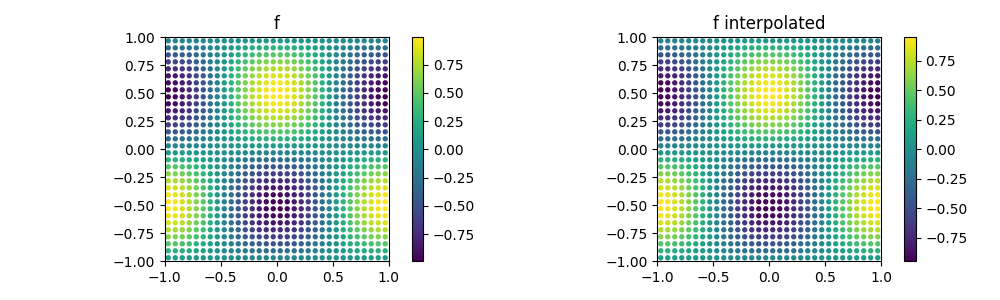

In [13]:
import matplotlib.pyplot as plt

fig, axis = plt.subplots(1, 2, figsize = (10,3), squeeze = False)

markerSize = 8

c = axis[0,0].scatter(queryPositions[:,0].cpu(), queryPositions[:,1].cpu(), c = f.cpu(), s = markerSize)
axis[0,0].set_title("f")
fig.colorbar(c, ax = axis[0,0])

axis[0,0].set_aspect('equal', adjustable='box')
axis[0,0].set_xlim(-1,1)
axis[0,0].set_ylim(-1,1)


c = axis[0,1].scatter(queryPositions[:,0].cpu(), queryPositions[:,1].cpu(), c = f_interpolated.detach().cpu(), s = markerSize)
axis[0,1].set_title("f interpolated")
fig.colorbar(c, ax = axis[0,1])

axis[0,1].set_aspect('equal', adjustable='box')
axis[0,1].set_xlim(-1,1)
axis[0,1].set_ylim(-1,1)

fig.tight_layout()

In [14]:
queryDensities

tensor([1.0012, 1.0012, 1.0012,  ..., 1.0012, 1.0012, 1.0012], device='cuda:0',
       grad_fn=<WarpFunctionWrapperBackward>)

In [15]:
from sphWarpCore.operations.wp_laplacian import computeSPHLaplacian_warpBackend
from sphWarpCore.operations.wp_gradient import computeSPHGradient_warpBackend

In [16]:
f_gradient = computeSPHGradient_warpBackend(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f, f,
        domain,
        mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2,
        adjacency = adjacency,
        gradientMode=GradientScheme.Difference
)
f_gradient_gradient = computeSPHGradient_warpBackend(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f_gradient, f_gradient,
        domain,
        mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2,
        adjacency = adjacency,
        gradientMode=GradientScheme.Difference
)

[Kernel.add_overload] Creating new overload for computeSPHGradientTensor_Kernel: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1v1f4_a1v1f4_a1f4_a1f4_a1b_u4_i4_i4_a1i8_a1i8_a1i8_i4_i4_i4_a1v2f4
Module sphWarpCore.operations.wp_gradient 3874b4d load on device 'cuda:0' (block_dim=256) ...
            grad_f_interpolated += outerTensorProduct((fj + fi) * apparentVolume, kernelGradient, grad_f_interpolated, numDims, flatInputShape, flatOutputShape)

    Compile CUDA (arch=120, mode=release, block_dim=256) ...
"wp_sphWarpCore.operations.wp_gradient_3874b4d.cu": using precompiled header file "/home/lu26029/.cache/warp/1.12.0/wp_sphWarpCore.radiusSearch.wp_compactHash_e2c9126.pch"
    Compile CUDA (arch=120, mode=release, block_dim=256) took 133.65 ms
Module sphWarpCore.operations.wp_gradient 3874b4d load on device 'cuda:0' (block_dim=256) took 175.78 ms  (compiled)
[Kernel.add_overload] Creating new overload for computeSPHGradientTensor_Kernel: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1v2

In [32]:
f_mat =torch.zeros_like(f_gradient_gradient)#
f_mat[:,0,0] = f
f_mat[:,0,1] = f
f_mat[:,1,0] = f
f_mat[:,1,1] = f

In [34]:
laplacian = computeSPHLaplacian_warpBackend(
        queryPositions, queryPositions,
        querySupports, querySupports,
        queryMasses, queryMasses,
        queryDensities, queryDensities,
        f_gradient, f_gradient,
        domain,
        mode = SupportScheme.Gather, kernel = KernelFunctions.Wendland2, 
        
        gradientMode=GradientScheme.Difference,         
        laplacianMode=LaplacianScheme.Dot, positiveDivergence=False,
        adjacency = adjacency
)

laplacian

computeSPHLaplacian_warpBackend: inputShape=torch.Size([2]), flatInputShape=2, outputShape=torch.Size([2]), flatOutputShape=2, numDims=1
[Kernel.add_overload] Creating new overload for computeSPHLaplacianTensor_Kernel: a1v2f4_a1v2f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1f4_a1v2f4_a1v2f4_a1f4_a1f4_a1b_u4_i4_i4_i4_b_a1i8_a1i8_a1i8_i4_i4_i4_i4_a1v2f4
[Module.load] Module hash changed, recompiling: sphWarpCore.operations.wp_laplacian (f84ba1e3 -> d2fe2e41)
Module sphWarpCore.operations.wp_laplacian d2fe2e4 load on device 'cuda:0' (block_dim=256) ...
            proj += q_ij[base + k] * n_ij[k]

            laplacian_result += computeDotLaplacian(q_ij, n_ij, kernelGradient, r_ij, h_ij, flatInputShape, dim)

            proj += q_ij[base + k] * n_ij[k]

            laplacian_result += computeDotLaplacian(q_ij, n_ij, kernelGradient, r_ij, h_ij, flatInputShape, dim)

    Compile CUDA (arch=120, mode=release, block_dim=256) ...
"wp_sphWarpCore.operations.wp_laplacian_d2fe2e4.cu": using precompiled header 

tensor([[  0.5430, -55.9744],
        [  1.6081, -53.8233],
        [  2.6114, -49.6039],
        ...,
        [  2.6114, -49.6039],
        [  1.6081, -53.8232],
        [  0.5430, -55.9744]], device='cuda:0', grad_fn=<ViewBackward0>)

In [36]:
from diffSPH.enums import Operation, SupportScheme, GradientMode, LaplacianMode
from diffSPH.operations import SPHOperation
neighborhood = state.get('noghost')
simulationState.densities = queryDensities

diffSPHLaplacian = SPHOperation(
        simulationState,
        quantity = f_gradient,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Laplacian,
        supportScheme = SupportScheme.Gather,
        gradientMode = GradientMode.Difference,
        laplacianMode= LaplacianMode.dot,
        correctionTerms= [],
        positiveDivergence=False
        )
diffSPHLaplacian

tensor([[  0.5430, -55.9744],
        [  1.6081, -53.8233],
        [  2.6114, -49.6039],
        ...,
        [  2.6114, -49.6039],
        [  1.6081, -53.8232],
        [  0.5430, -55.9744]], device='cuda:0', grad_fn=<LaplacianBackward>)

In [37]:
diffSPHLaplacian / laplacian

tensor([[1.0000, 1.0000],
        [1.0000, 1.0000],
        [1.0000, 1.0000],
        ...,
        [1.0000, 1.0000],
        [1.0000, 1.0000],
        [1.0000, 1.0000]], device='cuda:0', grad_fn=<DivBackward0>)

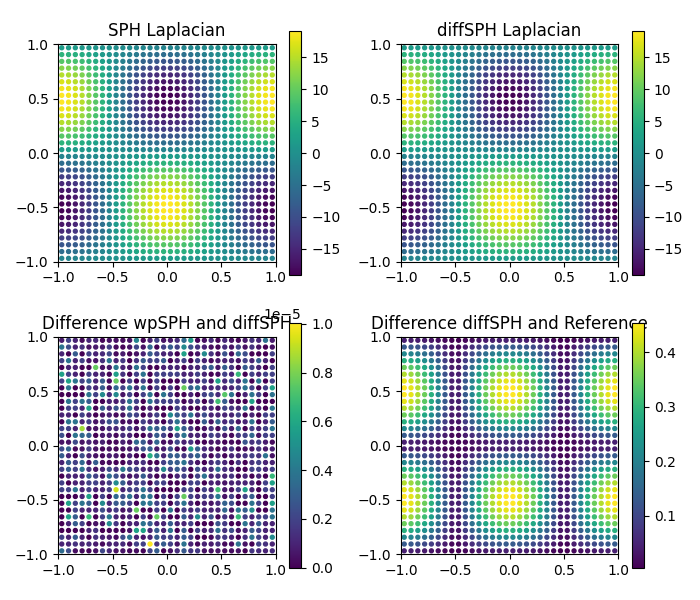

In [24]:
fig, axis = plt.subplots(2, 2, figsize = (7,6), squeeze = False)

c = axis[0,0].scatter(queryPositions[:,0].cpu(), queryPositions[:,1].cpu(), c = laplacian.detach().cpu(), s = markerSize)
axis[0,0].set_title("SPH Laplacian")
fig.colorbar(c, ax = axis[0,0])

c = axis[0,1].scatter(queryPositions[:,0].cpu(), queryPositions[:,1].cpu(), c = diffSPHLaplacian.detach().cpu(), s = markerSize)
axis[0,1].set_title("diffSPH Laplacian")
fig.colorbar(c, ax = axis[0,1])

# f = torch.cos(np.pi * referencePositions[:,0]) * torch.sin(np.pi * referencePositions[:,1])
referenceLaplacian = -2 * np.pi**2 * f

diff = torch.abs(laplacian - diffSPHLaplacian)
c = axis[1,0].scatter(queryPositions[:,0].cpu(), queryPositions[:,1].cpu(), c = diff.detach().cpu(), s = markerSize)
axis[1,0].set_title("Difference wpSPH and diffSPH")
fig.colorbar(c, ax = axis[1,0])

diff = torch.abs(diffSPHLaplacian - referenceLaplacian)
c = axis[1,1].scatter(queryPositions[:,0].cpu(), queryPositions[:,1].cpu(), c = diff.detach().cpu(), s = markerSize)
axis[1,1].set_title("Difference diffSPH and Reference")
fig.colorbar(c, ax = axis[1,1])


for ax in axis.flatten():
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-1,1)
    ax.set_ylim(-1,1)

fig.tight_layout()


tensor([[1.4758, 1.4758],
        [1.4758, 1.4758],
        [1.4758, 1.4758],
        ...,
        [1.4758, 1.4758],
        [1.4758, 1.4758],
        [1.4758, 1.4758]], device='cuda:0', grad_fn=<DivBackward0>)

In [ ]:
fvec = torch.rand((x.shape[0],2), device = x.device)

fvec_interpolated = computeSPHInterpolant_warpBackend(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        fvec, fvec,
        domain,
        mode = mode,
        adjacency = adjacency
)

TypeError: computeSPHInterpolant_warpBackend() missing 1 required positional argument: 'kernel'

In [ ]:
import matplotlib.pyplot as plt

fig, axis = plt.subplots(2, 2, figsize = (10,7), squeeze = False)

markerSize = 8

c = axis[0,0].scatter(queryPositions[:,0].cpu(), queryPositions[:,1].cpu(), c = fvec[:,0].cpu(), s = markerSize)
axis[0,0].set_title("f")
fig.colorbar(c, ax = axis[0,0])

c = axis[0,1].scatter(queryPositions[:,0].cpu(), queryPositions[:,1].cpu(), c = fvec_interpolated[:,0].cpu(), s = markerSize)
axis[0,1].set_title("f interpolated")
fig.colorbar(c, ax = axis[0,1])

c = axis[1,0].scatter(queryPositions[:,0].cpu(), queryPositions[:,1].cpu(), c = fvec[:,1].cpu(), s = markerSize)
axis[1,0].set_title("f vec y")
fig.colorbar(c, ax = axis[1,0])

c = axis[1,1].scatter(queryPositions[:,0].cpu(), queryPositions[:,1].cpu(), c = fvec_interpolated[:,1].cpu(), s = markerSize)
axis[1,1].set_title("f vec y interpolated")
fig.colorbar(c, ax = axis[1,1])


for ax in axis.flatten():
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-1,1)
    ax.set_ylim(-1,1)

fig.tight_layout()

In [ ]:
f = torch.rand((x.shape[0],2,2), device = x.device)

f_interpolated = computeSPHInterpolant_warpBackend(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f, f,
        domain,
        mode = mode,
        adjacency = adjacency
)

In [ ]:
f = torch.rand((x.shape[0],3,3,3), device = x.device)

f_interpolated = computeSPHInterpolant_warpBackend(
        queryPositions, referencePositions,
        querySupports, referenceSupports,
        queryMasses, referenceMasses,
        queryDensities, referenceDensities,
        f, f,
        domain,
        mode = mode,
        adjacency = adjacency
)